In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

print("EDA environment ready!")

EDA environment ready!


In [4]:
processed_path = "../data/CICIDS2017/processed"

processed_files = glob.glob(os.path.join(processed_path, "*.csv"))

print("Number of processed files:", len(processed_files))

for file in processed_files:
    print(os.path.basename(file))

Number of processed files: 8
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Friday-WorkingHours-Morning.pcap_ISCX.csv
Monday-WorkingHours.pcap_ISCX.csv
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Tuesday-WorkingHours.pcap_ISCX.csv
Wednesday-workingHours.pcap_ISCX.csv


In [5]:
label_counts = {}

for file in processed_files:
    print("Reading:", os.path.basename(file))
    
    temp = pd.read_csv(file, usecols=["Label"])
    
    counts = temp["Label"].value_counts()
    
    for label, count in counts.items():
        label_counts[label] = label_counts.get(label, 0) + count

label_distribution = pd.Series(label_counts).sort_values(ascending=False)

print("\nOverall Label Distribution:")
print(label_distribution)

Reading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Reading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
Reading: Friday-WorkingHours-Morning.pcap_ISCX.csv
Reading: Monday-WorkingHours.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
Reading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
Reading: Tuesday-WorkingHours.pcap_ISCX.csv
Reading: Wednesday-workingHours.pcap_ISCX.csv

Overall Label Distribution:
BENIGN                        2146899
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack � Brute Force         1470
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
He

In [6]:
label_percentage = (
    label_distribution / label_distribution.sum() * 100
).round(2)

eda_summary = pd.DataFrame({
    "Count": label_distribution,
    "Percentage": label_percentage
})

eda_summary

,Count,Percentage
BENIGN,2146899,83.45
DoS Hulk,172846,6.72
DDoS,128014,4.98
PortScan,90694,3.53
DoS GoldenEye,10286,0.40
FTP-Patator,5931,0.23
DoS slowloris,5385,0.21
DoS Slowhttptest,5228,0.20
SSH-Patator,3219,0.13
Bot,1948,0.08


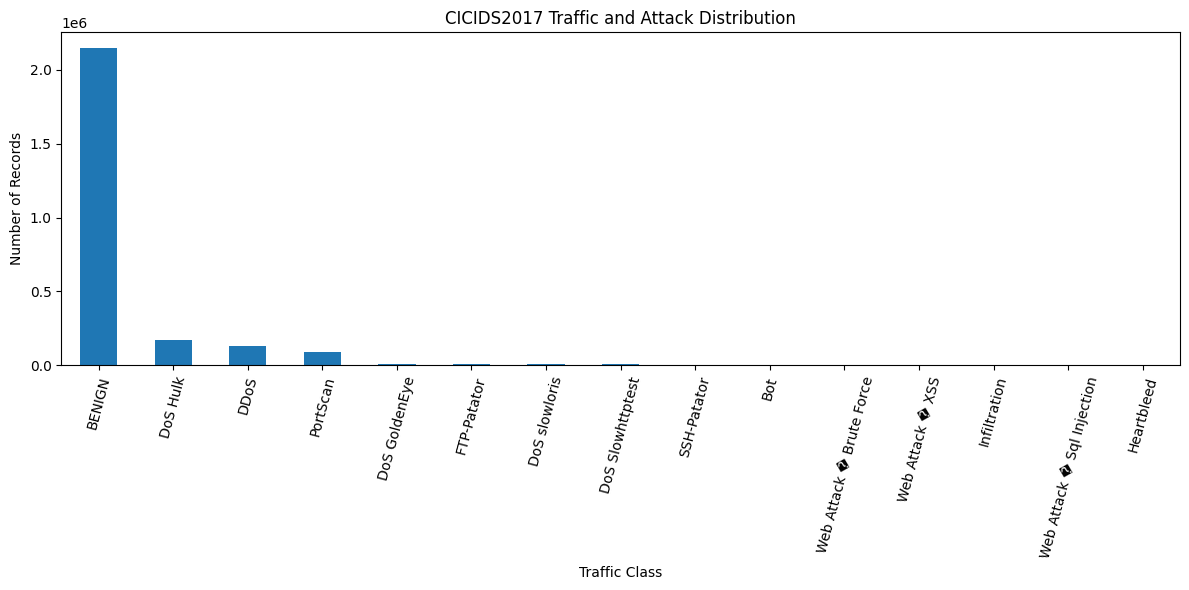

In [7]:
plt.figure(figsize=(12, 6))

label_distribution.plot(kind="bar")

plt.title("CICIDS2017 Traffic and Attack Distribution")
plt.xlabel("Traffic Class")
plt.ylabel("Number of Records")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

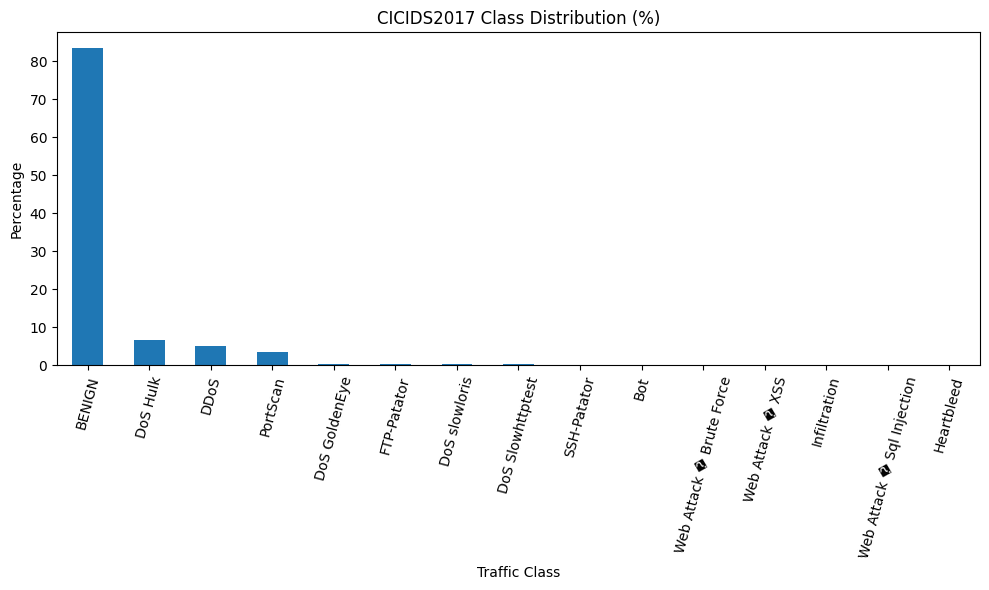

In [8]:
plt.figure(figsize=(10, 6))

label_percentage.plot(kind="bar")

plt.title("CICIDS2017 Class Distribution (%)")
plt.xlabel("Traffic Class")
plt.ylabel("Percentage")
plt.xticks(rotation=75)
plt.tight_layout()

plt.show()

In [9]:
benign_count = label_distribution.get("BENIGN", 0)
total_count = label_distribution.sum()

benign_percentage = benign_count / total_count * 100

print("Total records:", total_count)
print("BENIGN records:", benign_count)
print(f"BENIGN percentage: {benign_percentage:.2f}%")
print(f"Attack percentage: {100 - benign_percentage:.2f}%")

Total records: 2572640
BENIGN records: 2146899
BENIGN percentage: 83.45%
Attack percentage: 16.55%


In [10]:
sample_file = processed_files[0]

df_sample = pd.read_csv(sample_file)

print("File:", os.path.basename(sample_file))
print("Shape:", df_sample.shape)

print("\nFirst 10 columns:")
print(df_sample.columns[:10].tolist())

File: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
Shape: (223082, 79)

First 10 columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std']


In [11]:
df_sample.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [12]:
numeric_columns = df_sample.select_dtypes(include=np.number).columns

print("Number of numerical features:", len(numeric_columns))

df_sample[numeric_columns].describe().T

Number of numerical features: 78


,count,mean,std,min,25%,50%,75%,max
Destination Port,223082.0,8.979381e+03,1.984477e+04,0.0,80.0,80.0,80.00,65532.0
Flow Duration,223082.0,1.643543e+07,3.166173e+07,-1.0,81792.0,1537869.5,8958819.25,119999937.0
Total Fwd Packets,223082.0,4.905806e+00,1.551075e+01,1.0,2.0,3.0,5.00,1932.0
Total Backward Packets,223082.0,4.612134e+00,2.188157e+01,0.0,1.0,4.0,5.00,2942.0
Total Length of Fwd Packets,223082.0,9.497895e+02,3.267283e+03,0.0,26.0,30.0,62.00,183012.0
...,...,...,...,...,...,...,...,...
Active Min,223082.0,1.797404e+05,7.886858e+05,0.0,0.0,0.0,1966.00,100000000.0
Idle Mean,223082.0,1.044529e+07,2.195380e+07,0.0,0.0,0.0,8421148.50,120000000.0
Idle Std,223082.0,3.655060e+06,1.282667e+07,0.0,0.0,0.0,0.00,65300000.0
Idle Max,223082.0,1.303179e+07,2.704448e+07,0.0,0.0,0.0,8446779.25,120000000.0


In [13]:
feature_stats = df_sample[numeric_columns].describe().T

feature_stats["range"] = (
    feature_stats["max"] - feature_stats["min"]
)

feature_stats.sort_values(
    "range",
    ascending=False
).head(15)

,count,mean,std,min,25%,50%,75%,max,range
Flow Bytes/s,223082.0,5.526803e+05,1.694721e+07,-12000000.0,11.82332,9.308987e+02,1.970415e+04,2.070000e+09,2.082000e+09
Fwd IAT Min,223082.0,2.098449e+05,3.817745e+06,-12.0,1.00000,4.000000e+00,1.240000e+02,1.200000e+08,1.200000e+08
Flow IAT Max,223082.0,1.365071e+07,2.681971e+07,-1.0,69659.75000,1.502064e+06,8.556912e+06,1.200000e+08,1.200000e+08
Idle Mean,223082.0,1.044529e+07,2.195380e+07,0.0,0.00000,0.000000e+00,8.421148e+06,1.200000e+08,1.200000e+08
Bwd IAT Total,223082.0,6.643066e+06,2.210361e+07,0.0,0.00000,4.480600e+04,1.133642e+06,1.200000e+08,1.200000e+08
Idle Min,223082.0,7.847862e+06,1.993090e+07,0.0,0.00000,0.000000e+00,7.525541e+06,1.200000e+08,1.200000e+08
Fwd IAT Mean,223082.0,2.570909e+06,5.963484e+06,0.0,222.50000,1.095650e+04,2.032967e+06,1.200000e+08,1.200000e+08
Fwd IAT Max,223082.0,1.314937e+07,2.761541e+07,0.0,315.00000,2.418750e+04,7.762809e+06,1.200000e+08,1.200000e+08
Bwd IAT Max,223082.0,4.622038e+06,1.626719e+07,0.0,0.00000,3.638550e+04,1.114660e+06,1.200000e+08,1.200000e+08
Bwd IAT Mean,223082.0,9.589442e+05,4.612492e+06,0.0,0.00000,1.091088e+04,2.706666e+05,1.200000e+08,1.200000e+08
